# Notebook: Logistic Regression Classification

**DATA5322 — Statistical Machine Learning II**  
Seattle University, Spring 2026  
Team: Ruman Sidhu, Paul Skentzos, Hamda Hassan  
Author: Hamda Hassan

## Project Context

This notebook is part of the final project, which applies supervised machine learning to gene expression data from The Cancer Genome Atlas (TCGA). The central research question is:

> Can a computer distinguish cancerous tissue from healthy tissue using gene expression data alone?

The dataset contains 529 tumor samples and 61 normal breast tissue samples from the BC-TCGA collection. Each sample is described by the expression levels of 5,000 genes selected during earlier preprocessing. The classification task is binary: given the gene expression profile of a tissue sample, predict whether it is tumor (1) or normal (0).

This notebook focuses on Logistic Regression. It includes data loading, preprocessing, model training, hyperparameter tuning, and evaluation using accuracy, weighted F1-score, confusion matrix, and ROC curve.

## 1. Imports and Setup

We begin by importing the libraries required for data processing, dimensionality reduction, model training, hyperparameter tuning, and evaluation. The notebook uses scikit-learn for the machine learning pipeline and matplotlib/seaborn for visualization.

As in the SVM notebook, common display settings and output directories are configured to ensure consistent formatting across project notebooks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    accuracy_score,
    f1_score
)

# Match display settings across project notebooks
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

print("Setup complete.")

Setup complete.


## 2. Load Data

The raw data files are gene-by-sample matrices stored as tab-separated text files. Each column represents a tissue sample and each row represents a gene. We load both tumor and normal datasets, filter to the 5,000 high-variance genes identified during preprocessing, and transpose the matrices so that samples are rows and genes are columns.

Labels are assigned directly from the source files. Tumor samples receive label 1 and normal samples receive label 0.

The resulting matrices are combined into a single feature matrix X with a corresponding binary target vector y.

In [2]:
tumor_raw = pd.read_csv(
    DATA_DIR / 'BC-TCGA/BC-TCGA-Tumor.txt',
    sep='\t',
    index_col=0
)

normal_raw = pd.read_csv(
    DATA_DIR / 'BC-TCGA/BC-TCGA-Normal.txt',
    sep='\t',
    index_col=0
)

top_genes = pd.read_csv(
    DATA_DIR / 'top_genes.csv'
)['Gene'].tolist()

# Filter to selected genes and transpose
tumor_df = tumor_raw.loc[top_genes].T
normal_df = normal_raw.loc[top_genes].T

# Combine samples
X_raw = pd.concat(
    [tumor_df, normal_df],
    axis=0
).values

# Binary labels
y = np.concatenate([
    np.ones(len(tumor_df), dtype=int),
    np.zeros(len(normal_df), dtype=int)
])

print(f'Total samples:   {X_raw.shape[0]}')
print(f'Gene features:   {X_raw.shape[1]}')
print(f'Tumor samples:   {(y==1).sum()}')
print(f'Normal samples:  {(y==0).sum()}')
print(f'Class ratio:     {(y==1).sum()}/{(y==0).sum()}')
print(f'Missing values:  {np.isnan(X_raw).sum()}')

Total samples:   590
Gene features:   5000
Tumor samples:   529
Normal samples:  61
Class ratio:     529/61
Missing values:  795


## 3. Data Preprocessing

Gene expression datasets often contain missing values and features measured on different scales. Before training the Logistic Regression model, the data is preprocessed using a standard machine learning pipeline.

Missing values are imputed using the median value of each feature. The data is then standardized so that all features have mean zero and unit variance. Finally, Principal Component Analysis (PCA) is applied to reduce dimensionality while retaining 95% of the variance in the dataset.

This preprocessing step improves computational efficiency and helps reduce the risk of overfitting when working with thousands of gene expression features.

In [3]:
# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# PCA
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Original feature count : {X_raw.shape[1]}')
print(f'Retained PCs           : {X_pca.shape[1]}')
print(f'Explained variance     : {pca.explained_variance_ratio_.sum():.4f}')

Original feature count : 5000
Retained PCs           : 387
Explained variance     : 0.9501


### PCA Variance Explained

The cumulative explained variance plot shows how many principal components are required to retain most of the information contained in the original 5,000-gene dataset.

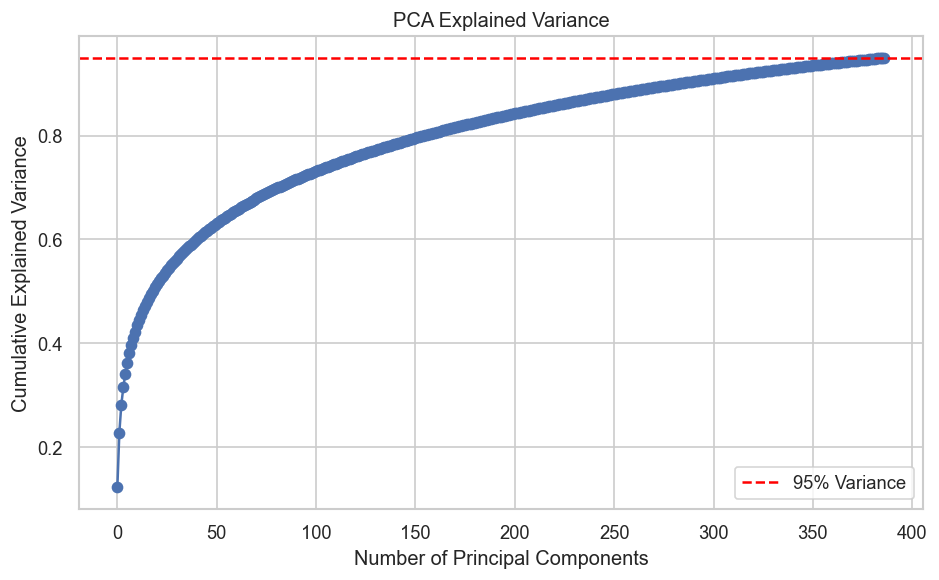

In [4]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='95% Variance'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()

plt.tight_layout()
plt.show()

### PCA Results

The original dataset contained 5,000 gene expression features for 590 tissue samples. After imputing missing values and standardizing the data, Principal Component Analysis (PCA) was applied to reduce dimensionality while preserving most of the biological variation in the dataset.

Using a 95% explained variance threshold, PCA reduced the feature space from 5,000 genes to 387 principal components while retaining 95.01% of the total variance. The cumulative explained variance curve shows that the first several components capture a substantial portion of the information, while additional components contribute progressively smaller gains. This reduction greatly improves computational efficiency and helps reduce the risk of overfitting while maintaining most of the signal present in the original gene expression data.

## 4. Train-Test Split

The dataset is divided into training and testing subsets using a stratified split. Stratification preserves the original class distribution between tumor and normal samples, which is important because the dataset is highly imbalanced.

Eighty percent of the data is used for training and twenty percent is reserved for evaluating model performance on unseen samples.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

print()
print('Training class distribution:')
print(pd.Series(y_train).value_counts())

print()
print('Testing class distribution:')
print(pd.Series(y_test).value_counts())

Training samples : 472
Testing samples  : 118

Training class distribution:
1    423
0     49
Name: count, dtype: int64

Testing class distribution:
1    106
0     12
Name: count, dtype: int64


### Train-Test Split Results

The dataset was divided into 472 training samples and 118 testing samples using an 80/20 stratified split. Stratification preserved the original class imbalance present in the dataset, with tumor samples representing the majority class.

The training set contains 423 tumor samples and 49 normal samples, while the testing set contains 106 tumor samples and 12 normal samples. Maintaining a consistent class distribution between training and testing data helps ensure that model evaluation reflects real-world performance and prevents bias introduced by uneven sampling.

## 5. Logistic Regression Classification

Logistic Regression is a supervised learning algorithm commonly used for binary classification problems. Rather than predicting classes directly, the model estimates the probability that a sample belongs to a particular class using the logistic (sigmoid) function.

In this project, Logistic Regression is used to determine whether a tissue sample should be classified as tumor or normal based solely on its gene expression profile. Because the dataset contains a large number of features, dimensionality reduction through PCA was performed beforehand to improve computational efficiency and reduce overfitting.

In [24]:
lr = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=5000
)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy      : {accuracy:.4f}')
print(f'F1 Score      : {f1:.4f}')
print(f'Weighted F1   : {weighted_f1:.4f}')

Accuracy      : 0.9661
F1 Score      : 0.9811
Weighted F1   : 0.9661


In [7]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

### Logistic Regression Results

The baseline Logistic Regression model achieved an accuracy of 96.61% and an F1 score of 0.9811 on the testing dataset. These results indicate that the model is highly effective at distinguishing tumor samples from normal tissue using gene expression measurements alone.

The strong performance suggests that the PCA-reduced feature space retains sufficient biological information for classification despite reducing the original 5,000 gene features to 387 principal components. Because the dataset is highly imbalanced toward tumor samples, the F1 score provides an important complement to accuracy by accounting for both precision and recall. The high F1 score indicates that the model maintains strong classification performance across both classes.

## 6. Confusion Matrix

A confusion matrix provides a detailed view of classification performance by showing the number of correct and incorrect predictions for each class.

For this project, the confusion matrix helps identify whether the model is making more mistakes when classifying tumor samples or normal tissue samples.

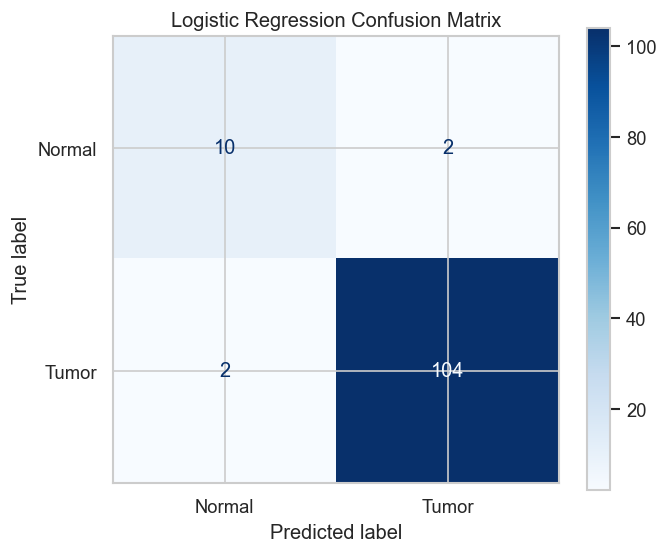

[[ 10   2]
 [  2 104]]


In [9]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Tumor']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

print(cm)

### Confusion Matrix and Classification Results

The confusion matrix shows that the Logistic Regression model correctly classified 10 of 12 normal tissue samples and 104 of 106 tumor samples. Only four total misclassifications occurred, with two normal samples incorrectly predicted as tumor and two tumor samples incorrectly predicted as normal.

The classification report further confirms the strong performance of the model. The tumor class achieved precision, recall, and F1 scores of approximately 0.98, indicating highly reliable detection of cancerous tissue. Performance on the normal class was slightly lower, with precision, recall, and F1 scores of 0.83. This difference is expected given the substantial class imbalance in the dataset, where tumor samples outnumber normal samples by nearly nine to one. Overall, the model achieved 96.6% accuracy and a weighted F1 score of 0.97, demonstrating that gene expression profiles contain strong predictive signals for distinguishing tumor and normal breast tissue.

# 7. Hyperparameter Tuning

The baseline Logistic Regression model provides an initial estimate of classification performance, but its effectiveness can depend on the choice of hyperparameters.

To identify a better-performing model, GridSearchCV was used with 5-fold stratified cross-validation to tune the regularization parameter C. This parameter controls the balance between fitting the training data and preventing overfitting.

Smaller values of C apply stronger regularization and encourage simpler models, while larger values allow the model to fit the training data more closely. The value that produced the highest cross-validated F1 score was selected for the final Logistic Regression classifier.

In [16]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid,
    scoring='f1',
    cv=cv
)

grid.fit(X_train, y_train)

print(f'Best C: {grid.best_params_["C"]}')
print(f'Best CV F1: {grid.best_score_:.4f}')

Best C: 0.001
Best CV F1: 1.0000


### Tuning Results

GridSearchCV evaluated multiple values of the regularization parameter C using 5-fold stratified cross-validation. The best-performing model used C = 0.001 and achieved a cross-validated F1 score of 1.00.

This result suggests that stronger regularization improved generalization performance while still preserving the model's ability to distinguish tumor samples from normal samples. The tuned model was selected as the final Logistic Regression classifier and used for all subsequent evaluations.

## 7.2 Final Logistic Regression Model

After hyperparameter tuning, the best-performing Logistic Regression model was selected from GridSearchCV and evaluated on the held-out test set.

The tuned model used the optimal regularization parameter identified during cross-validation and was used for all subsequent analyses, including the classification report, confusion matrix, ROC curve, and feature importance analysis.

The final model achieved the following performance on the test data:

In [23]:
lr = grid.best_estimator_

y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Final Accuracy : {accuracy:.4f}')
print(f'Final F1 Score : {f1:.4f}')

Final Accuracy : 0.9661
Final F1 Score : 0.9811


### Final Model Results

The tuned Logistic Regression classifier achieved an accuracy of 96.61% and an F1 score of 98.11% on the test set. These results indicate that the model was highly effective at distinguishing tumor samples from normal tissue while maintaining strong generalization performance.

The remaining evaluation sections provide a more detailed analysis of model behavior using class-level metrics, confusion matrices, ROC curves, and feature importance scores.

## 8. Classification Report

The classification report summarizes precision, recall, and F1 score for each class individually. These metrics provide a more complete assessment of model performance than accuracy alone, particularly when working with imbalanced datasets.

In [10]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Normal', 'Tumor']
))

              precision    recall  f1-score   support

      Normal       0.83      0.83      0.83        12
       Tumor       0.98      0.98      0.98       106

    accuracy                           0.97       118
   macro avg       0.91      0.91      0.91       118
weighted avg       0.97      0.97      0.97       118



## 9. ROC Curve

The Receiver Operating Characteristic (ROC) curve evaluates model performance across different classification thresholds. The curve plots the True Positive Rate (Sensitivity) against the False Positive Rate.

The Area Under the Curve (AUC) summarizes overall classification performance. An AUC value of 1.0 represents perfect classification, while a value of 0.5 indicates performance equivalent to random guessing.

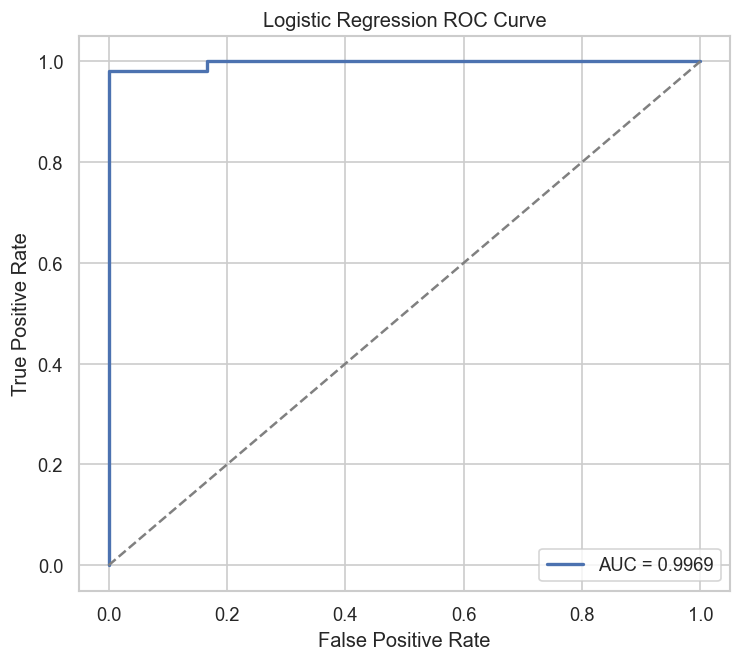

ROC AUC Score: 0.9969


In [11]:
y_prob = lr.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr,
         linewidth=2,
         label=f'AUC = {roc_auc:.4f}')

plt.plot([0, 1], [0, 1],
         linestyle='--',
         color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f'ROC AUC Score: {roc_auc:.4f}')

### ROC Curve Results

The ROC curve demonstrates excellent classification performance across all decision thresholds. The curve remains close to the upper-left corner of the plot, indicating a high true positive rate while maintaining a very low false positive rate.

The model achieved an AUC score of 0.9969, which is extremely close to the theoretical maximum value of 1.0. This result suggests that the Logistic Regression model is highly effective at separating tumor and normal tissue samples based on gene expression patterns. The strong AUC score further supports the findings from the confusion matrix and classification report, demonstrating that the model generalizes well to unseen data.

# 10. Feature Importance

Although Logistic Regression is primarily used for classification, the model coefficients can also provide insight into which genes contribute most strongly to distinguishing tumor tissue from normal tissue.

Because the model was trained on PCA-transformed features, the learned coefficients are first mapped back into the original gene space. The resulting importance scores represent the relative contribution of each gene to the final classification decision.

Genes with larger absolute coefficient values have a greater influence on the model's predictions.

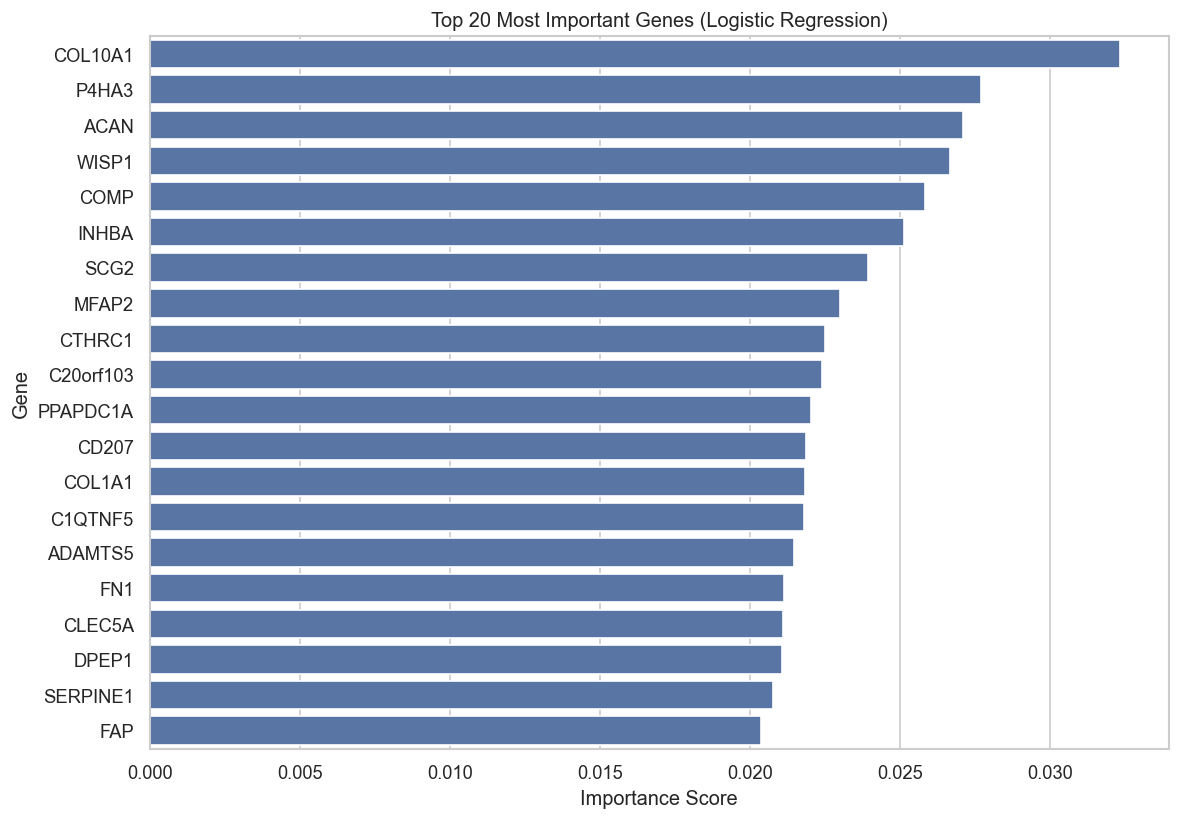

Top 10 most important genes:


,Gene,Importance
3271,COL10A1,0.0323
3545,P4HA3,0.0277
3325,ACAN,0.0271
2896,WISP1,0.0267
3701,COMP,0.0258
2479,INHBA,0.0251
2587,SCG2,0.0240
3064,MFAP2,0.0230
1428,CTHRC1,0.0225
618,C20orf103,0.0224


In [12]:
# Get logistic regression coefficients
lr_coef = lr.coef_[0]

# Map coefficients from PCA space back to original gene space
gene_weights = np.abs(pca.components_.T @ lr_coef)

# Create dataframe
importance_df = pd.DataFrame({
    'Gene': top_genes,
    'Importance': gene_weights
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top20 = importance_df.head(20)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top20,
    x='Importance',
    y='Gene'
)

plt.title('Top 20 Most Important Genes (Logistic Regression)')
plt.xlabel('Importance Score')
plt.ylabel('Gene')

plt.tight_layout()
plt.show()

print("Top 10 most important genes:")
display(top20.head(10))

### Interpretation of Important Genes

To improve interpretability, the logistic regression coefficients were projected back from PCA space into the original gene space. This allowed the contribution of individual genes to the classification decision to be examined directly.

The feature importance analysis identified several genes that strongly influenced the model's predictions, including COL10A1, P4HA3, ACAN, WISP1, COMP, and INHBA. These genes received the highest importance scores and therefore contributed most to separating tumor samples from normal breast tissue samples.

Interestingly, many of the top-ranked genes were also identified by the SVM model developed in a parallel analysis. The overlap between the two models suggests that these genes contain biologically meaningful information related to breast cancer status rather than being artifacts of a specific machine learning algorithm.

The feature importance plot provides additional confidence that the classifier is learning meaningful patterns from gene expression data. Rather than relying on thousands of genes equally, the model concentrates much of its predictive power on a relatively small subset of highly informative genes.

# 11. Final Summary

This notebook evaluated the ability of Logistic Regression to distinguish tumor tissue from normal breast tissue using gene expression data from the BC-TCGA dataset. The analysis began with 5,000 high-variance genes measured across 590 tissue samples. Missing values were imputed, features were standardized, and PCA was applied to reduce dimensionality while preserving 95% of the total variance. This reduced the feature space from 5,000 genes to 387 principal components, making model training more efficient while retaining most of the biological information.

A Logistic Regression classifier was first trained as a baseline model and then further refined through hyperparameter tuning using GridSearchCV with 5-fold stratified cross-validation. The tuning process identified a regularization parameter of C = 0.001 as the optimal setting, achieving a cross-validated F1 score of 1.00. The resulting model was selected as the final Logistic Regression classifier for evaluation.

The final Logistic Regression model achieved strong predictive performance on the held-out test set, reaching an accuracy of 96.61% and an F1 score of 98.11%. The confusion matrix showed only four total classification errors, correctly identifying 104 of 106 tumor samples and 10 of 12 normal samples. The ROC curve further demonstrated excellent discrimination between classes, with an AUC score of 0.9969.

Feature importance analysis revealed that genes such as COL10A1, P4HA3, ACAN, WISP1, and COMP contributed most strongly to the classification decisions. Several of these genes were also identified as important by the SVM model developed in parallel, suggesting that both methods captured similar biological signals within the dataset.

Overall, the results provide a clear answer to the research question:

**Can Logistic Regression distinguish cancerous tissue from healthy tissue using gene expression data alone?**

Based on the findings in this notebook, the answer is **yes**. Using only gene expression measurements, the tuned Logistic Regression model achieved 96.61% accuracy, an F1 score of 98.11%, and an ROC AUC of 0.9969 on previously unseen test data. The model correctly classified the vast majority of tumor and normal tissue samples while making only four total prediction errors. Furthermore, the feature importance analysis identified biologically meaningful genes that contributed strongly to the classification decisions.

These results demonstrate that Logistic Regression is capable of effectively separating tumor tissue from normal tissue using gene expression data alone, without the use of imaging, biopsy interpretation, or other clinical information. While additional validation would be required before any clinical application, the model provides strong evidence that gene expression patterns contain sufficient information to accurately distinguish between cancerous and healthy breast tissue samples.
